In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
url = r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\sample_submission.csv"
taxi_drivers = pd.read_csv(url)

In [3]:
taxi_drivers.head()

,id,target
0,0,0.0364
1,1,0.0364
2,2,0.0364
3,3,0.0364
4,4,0.0364


In [4]:
train_data = pd.read_csv(r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\train.csv")
test_data = pd.read_csv(r"C:\Users\andre\Downloads\porto-seguro-safe-driver-prediction\test.csv")

Чтобы максимизировать метрику соревнования max_gini = (1 - frac_pos) / 2, достаточно максимизировать AUC, так как формула AUC = 

In [5]:
train_data

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595207,1488013,0,3,1,10,0,0,0,0,0,...,4,1,9,6,0,1,1,0,1,1
595208,1488016,0,5,1,3,0,0,0,0,0,...,4,1,3,8,1,0,1,0,1,1
595209,1488017,0,1,1,10,0,0,1,0,0,...,3,2,2,6,0,0,1,0,0,0
595210,1488021,0,5,2,3,1,0,0,0,1,...,4,1,4,2,0,1,1,1,0,0


In [6]:
train_data.nunique()

id                595212
target                 2
ps_ind_01              8
ps_ind_02_cat          5
ps_ind_03             12
ps_ind_04_cat          3
ps_ind_05_cat          8
ps_ind_06_bin          2
ps_ind_07_bin          2
ps_ind_08_bin          2
ps_ind_09_bin          2
ps_ind_10_bin          2
ps_ind_11_bin          2
ps_ind_12_bin          2
ps_ind_13_bin          2
ps_ind_14              5
ps_ind_15             14
ps_ind_16_bin          2
ps_ind_17_bin          2
ps_ind_18_bin          2
ps_reg_01             10
ps_reg_02             19
ps_reg_03           5013
ps_car_01_cat         13
ps_car_02_cat          3
ps_car_03_cat          3
ps_car_04_cat         10
ps_car_05_cat          3
ps_car_06_cat         18
ps_car_07_cat          3
ps_car_08_cat          2
ps_car_09_cat          6
ps_car_10_cat          3
ps_car_11_cat        104
ps_car_11              5
ps_car_12            184
ps_car_13          70482
ps_car_14            850
ps_car_15             15
ps_calc_01            10


In [7]:
taxi_drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892816 entries, 0 to 892815
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      892816 non-null  int64  
 1   target  892816 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 13.6 MB


#### EDA

In [8]:
train_data.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
train_data.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


Как мы видим из распределения значения признаков - 'ps_ind_14' имеет уникальных значений [0:4], но практически все значения равны нулю, target также почти все значения равны нулю, остальные признаки распределены более менее равномерно

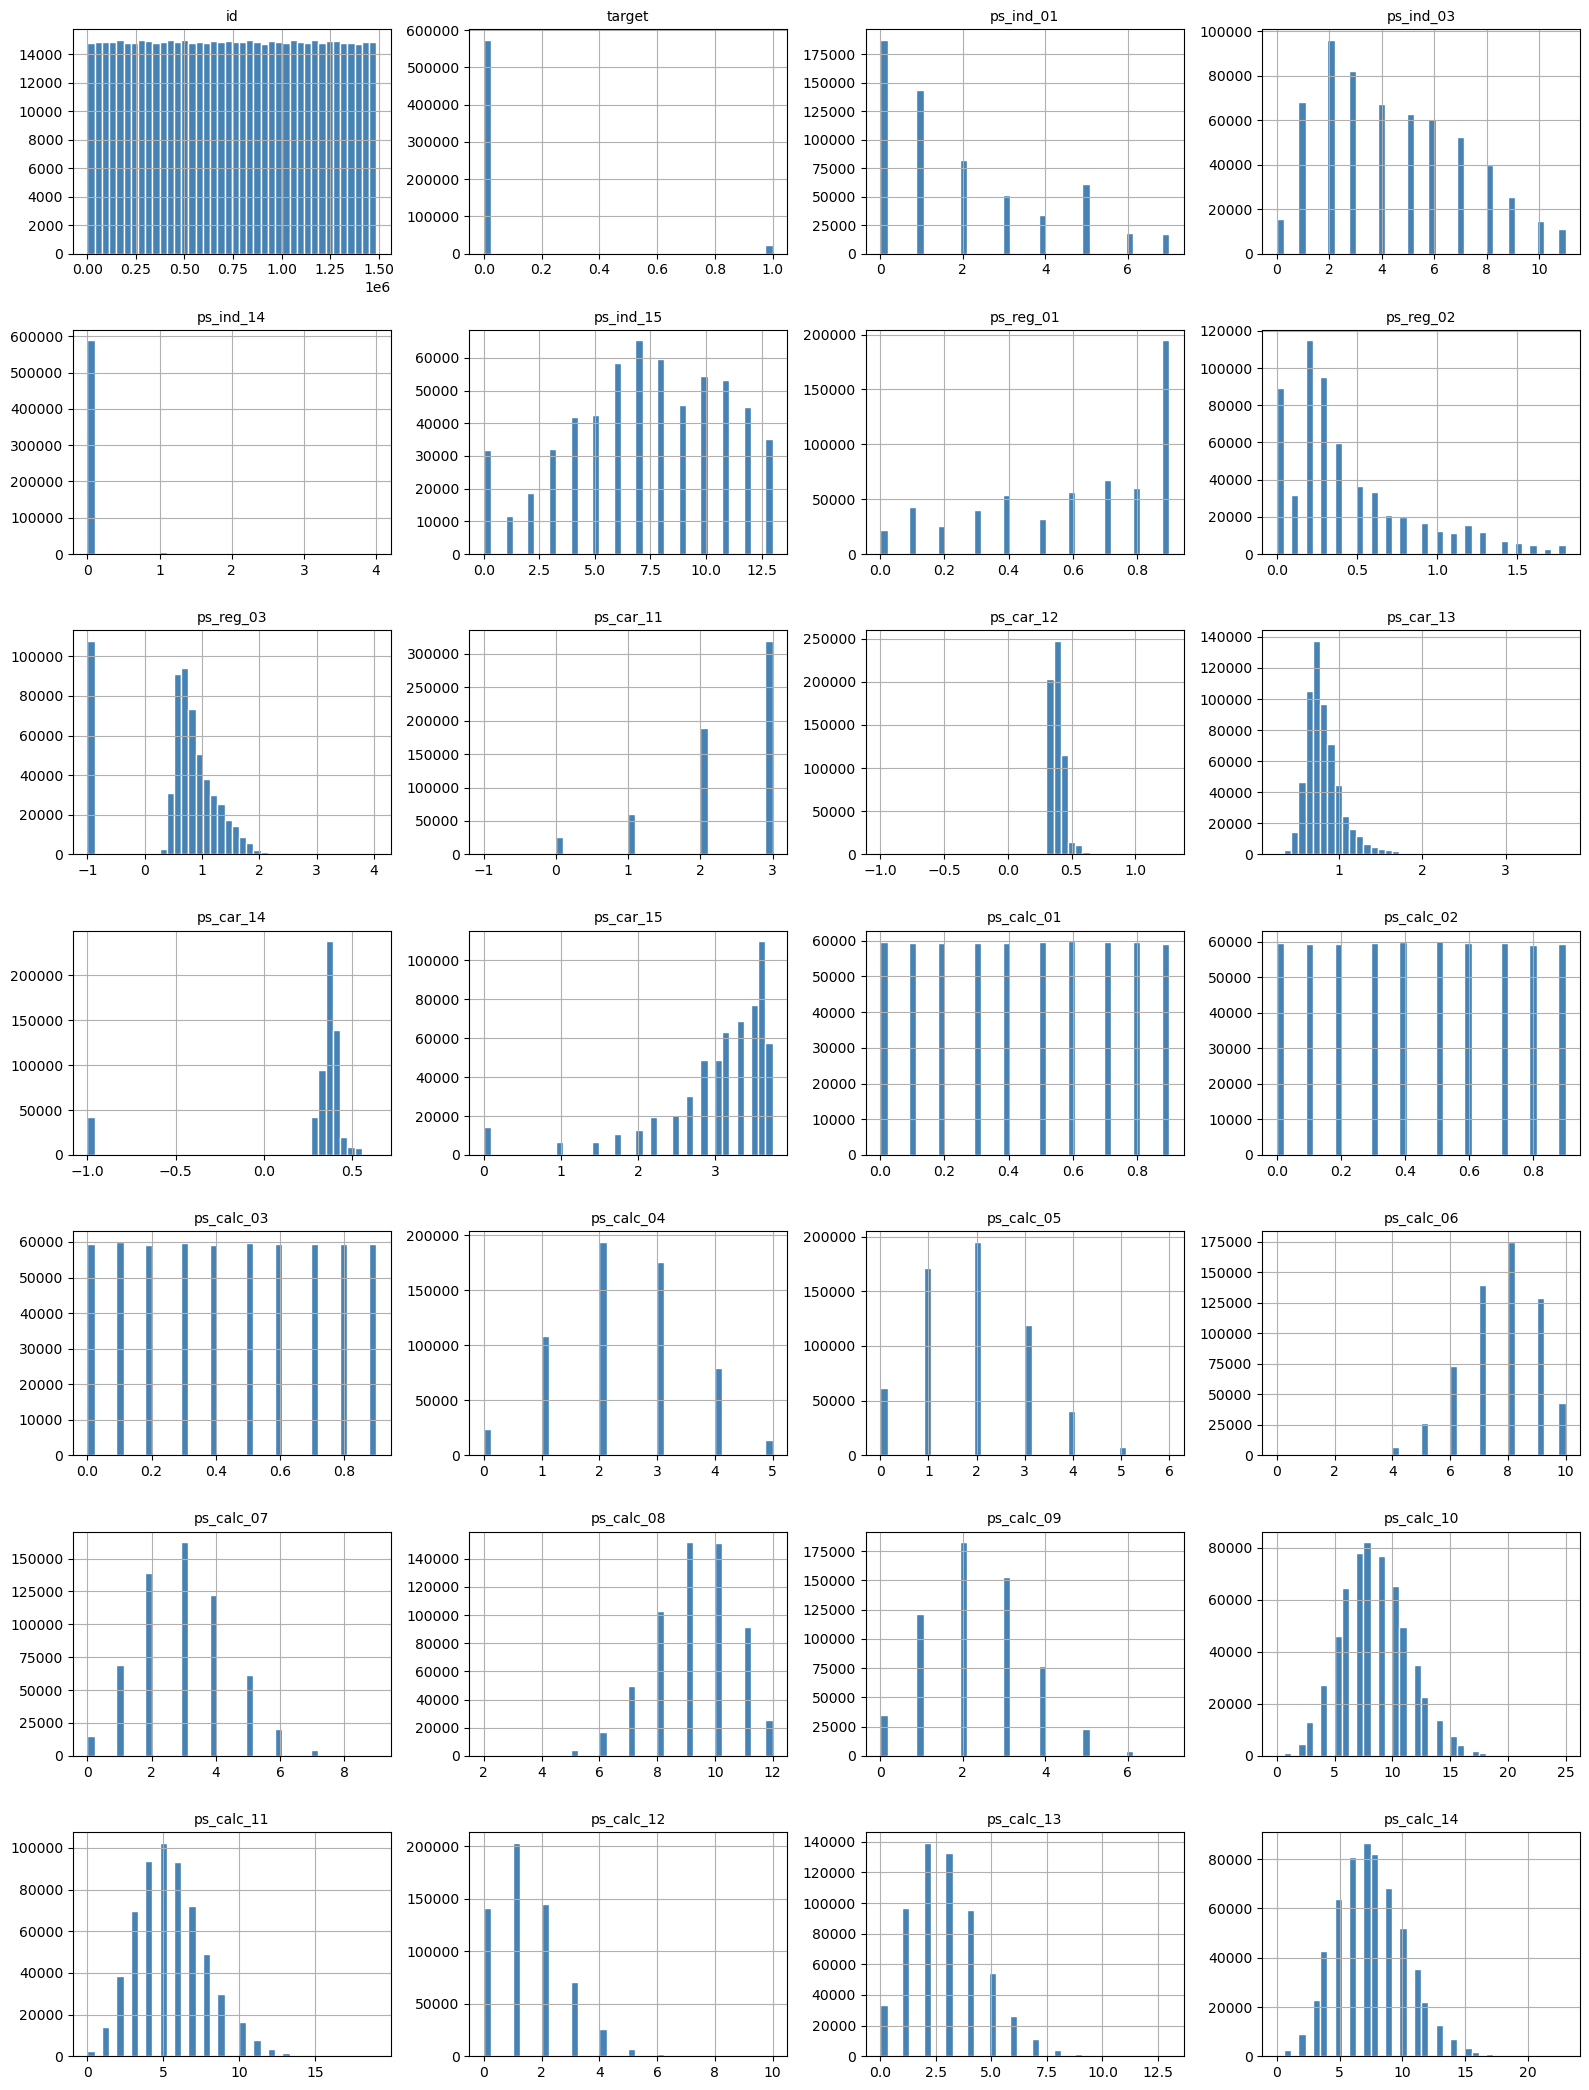

In [10]:
cols_to_keep = [col for col in train_data.columns if 'bin' not in col and 'cat' not in col]
n_cols = len(cols_to_keep)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(cols_to_keep):
    train_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(cols_to_keep), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
train_data['ps_calc_01'].unique()

array([0.6, 0.3, 0.5, 0.4, 0.7, 0.2, 0.1, 0.9, 0.8, 0. ])

Так как при построении корреляционной матрицы она получается огромной, есть смысл вывести пары с наибольшей корреляцией

In [12]:
corr_matrix = train_data.corr()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
strong_pairs = upper_tri.stack().reset_index()
strong_pairs.columns = ['Признак_1', 'Признак_2', 'Корреляция']
strong_pairs = strong_pairs[strong_pairs['Корреляция'] > 0.6]
strong_pairs = strong_pairs.sort_values('Корреляция', ascending=False)
print(strong_pairs)

          Признак_1  Признак_2  Корреляция
677   ps_ind_12_bin  ps_ind_14    0.890127
1435      ps_car_12  ps_car_13    0.671720
971       ps_reg_01  ps_reg_03    0.637035


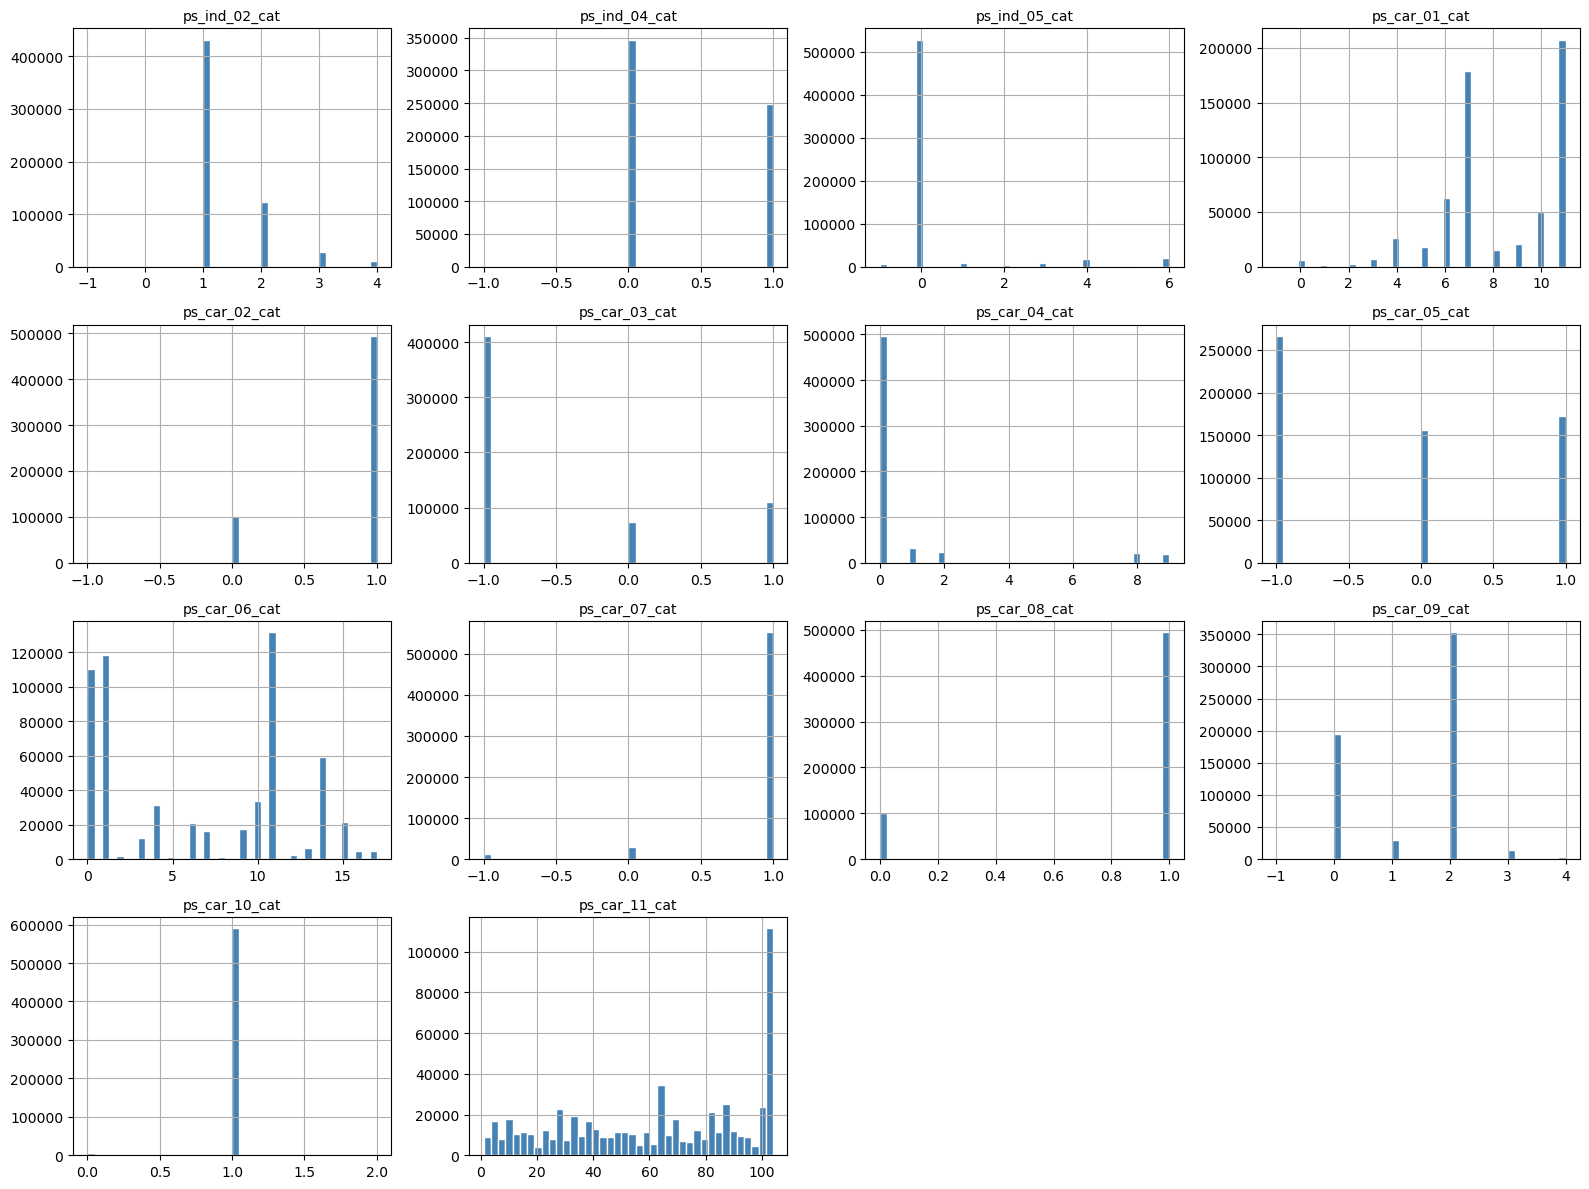

In [13]:
cols_to_save = [col for col in train_data.columns if 'cat' in col]
n_cols = len(cols_to_save)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(cols_to_save):
    train_data[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(cols_to_save), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Обучим LogisticRegression на всех признаках, затем после первого обучения выедлим главные из них а второстепенные удалим, поймём как признаки связаны между собой и таргетом.Уберём колонку с ID

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [15]:
y = train_data['target']
X = train_data.drop('target',axis=1)
X_train_xgb,X_test_xgb,y_train_xgb,y_test_xgb = train_test_split(X,y,test_size=0.2, random_state=42)
cols_to_scale = [col for col in X.columns if 'bin' not in col and col != 'id']
scaler_reg = StandardScaler()
X_train_scaled = X_train_xgb.copy()
X_test_scaled = X_test_xgb.copy()
X_train_scaled.drop('id', axis=1, inplace=True)
X_test_scaled.drop('id', axis=1, inplace=True)
X_train_scaled[cols_to_scale] = scaler_reg.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler_reg.transform(X_test_scaled[cols_to_scale])

In [16]:
X_train_scaled.head()

,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
39028,0.049891,-0.540387,0.213306,-0.844444,-0.300212,1,0,0,0,0,...,-0.617622,2.126826,0.075533,1.260116,0,0,1,0,1,0
478420,-0.958051,-0.540387,0.953862,1.182862,-0.300212,0,1,0,0,0,...,1.096935,-0.367428,0.075533,-0.560842,0,1,0,1,0,0
547268,-0.958051,-0.540387,-0.527249,-0.844444,-0.300212,0,1,0,0,0,...,-0.188983,0.463990,0.075533,0.895925,0,0,0,0,0,0
388290,-0.958051,2.472392,-0.156972,-0.844444,-0.300212,1,0,0,0,0,...,-1.474901,1.295408,-1.104534,0.895925,0,1,0,0,0,0
63342,-0.958051,-0.540387,-0.897527,1.182862,-0.300212,1,0,0,0,0,...,1.096935,1.295408,1.845635,1.260116,0,0,0,0,1,1


In [17]:
print(y_train_xgb.value_counts(normalize=True))
print(y_test_xgb.value_counts(normalize=True))

target
0    0.963649
1    0.036351
Name: proportion, dtype: float64
target
0    0.963165
1    0.036835
Name: proportion, dtype: float64


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

Создадим датафрейм с важностью признаков и посмотрим какие из них влияют на предсказание с наибольшей силой, из-за большого дисбаланса классов target нужно поставить class_weight = 'balanced'

In [19]:
model = LogisticRegression(max_iter = 1000,C=1,class_weight='balanced',random_state=42)
model.fit(X_train_scaled, y_train_xgb)
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test_xgb, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.625


как мы видим из графика PR-кривой, Precision и Recall обратно пропорциональны, это связано с большим дисбалансом в классе target,а именно (0-0.963649
1-0.036351)

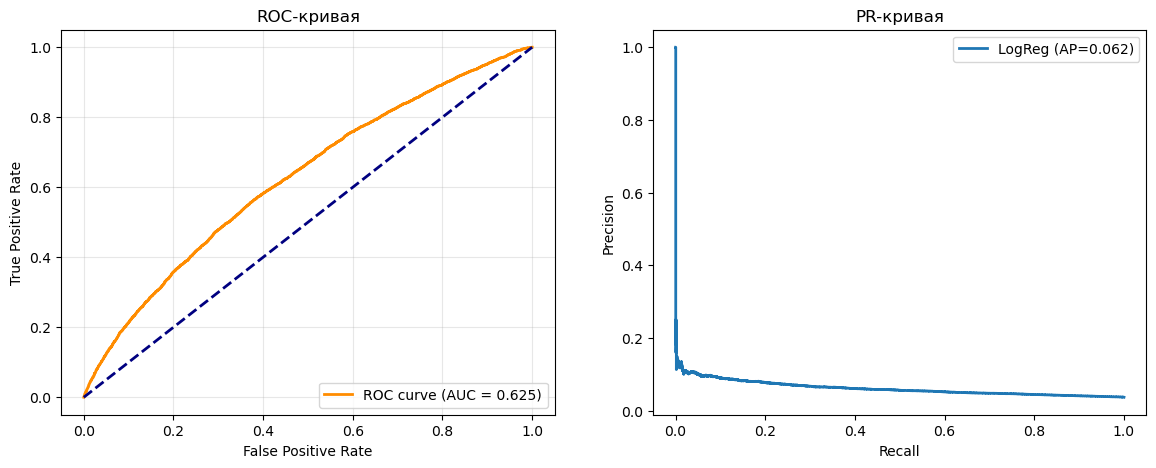

<Figure size 800x600 with 0 Axes>

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fpr, tpr, _ = roc_curve(y_test_xgb, y_proba)
plt.figure(figsize=(8, 6))
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)


prec, rec, _ = precision_recall_curve(y_test_xgb, y_proba)
ap = average_precision_score(y_test_xgb, y_proba)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

Как мы видим из таблицы некоторые коэффициенты пркатически не несут никакой информативности насчёт предсказывания вероятности отнесения к классу

In [21]:
coefficients = model.coef_[0]
feature_importance = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': coefficients,
    'importance_abs': np.abs(coefficients) 
}).sort_values('importance_abs', ascending=False)
print(feature_importance)

           feature  coefficient  importance_abs
16   ps_ind_17_bin     0.272085        0.272085
4    ps_ind_05_cat     0.136638        0.136638
5    ps_ind_06_bin    -0.131694        0.131694
6    ps_ind_07_bin     0.107692        0.107692
14       ps_ind_15    -0.106716        0.106716
7    ps_ind_08_bin     0.105082        0.105082
27   ps_car_07_cat    -0.103122        0.103122
15   ps_ind_16_bin    -0.099412        0.099412
8    ps_ind_09_bin    -0.096527        0.096527
36       ps_car_15     0.094452        0.094452
34       ps_car_13     0.075720        0.075720
20       ps_reg_03     0.072313        0.072313
33       ps_car_12     0.060419        0.060419
18       ps_reg_01     0.056620        0.056620
17   ps_ind_18_bin    -0.055692        0.055692
23   ps_car_03_cat     0.050965        0.050965
19       ps_reg_02     0.043377        0.043377
32       ps_car_11    -0.040657        0.040657
2        ps_ind_03     0.036150        0.036150
29   ps_car_09_cat     0.032548        0

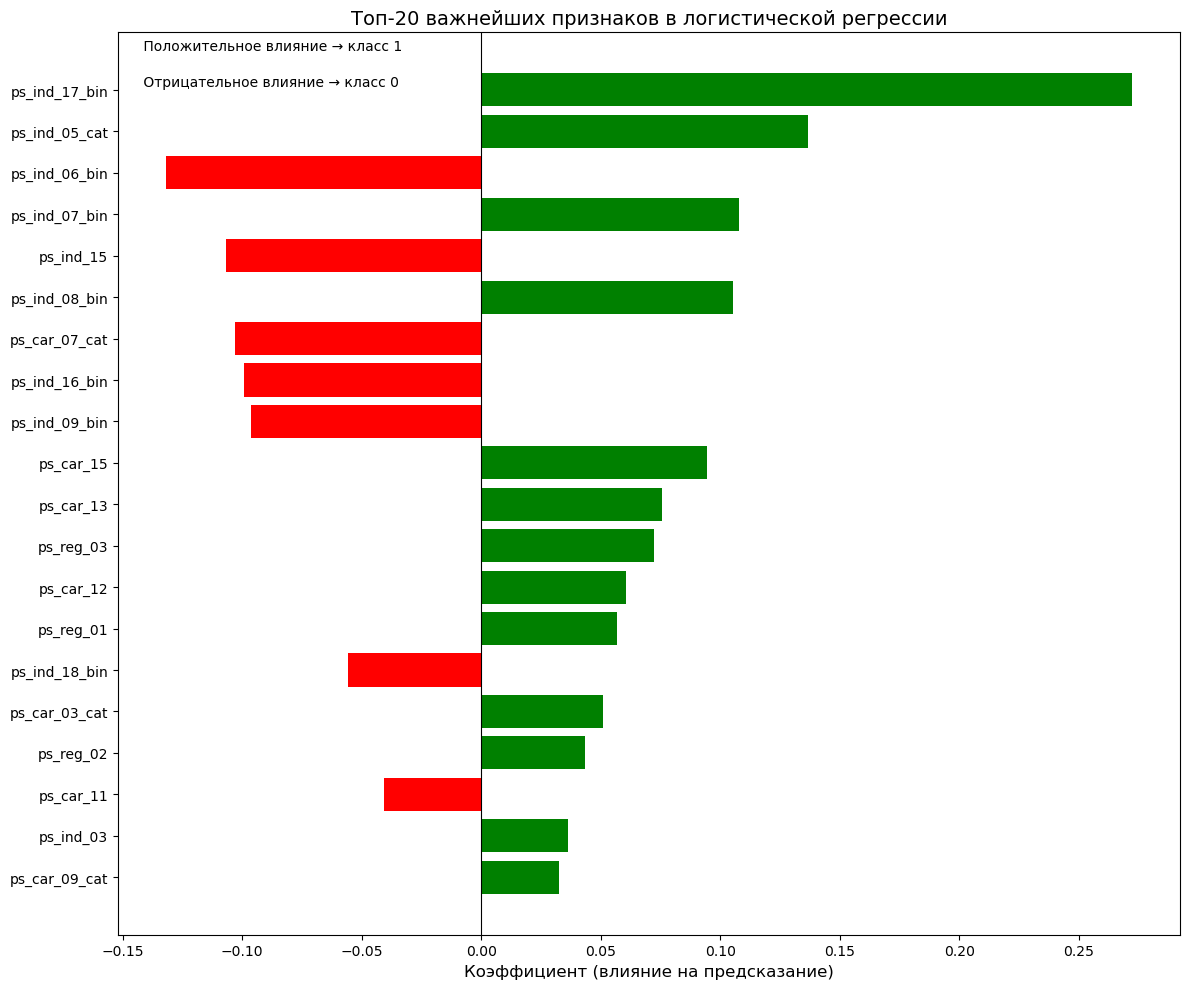

In [22]:
import matplotlib.pyplot as plt
top_n = 20
top_features = feature_importance.head(top_n)
plt.figure(figsize=(12, 10))
colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
plt.barh(top_features['feature'], top_features['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на предсказание)', fontsize=12)
plt.title(f'Топ-{top_n} важнейших признаков в логистической регрессии', fontsize=14)
plt.gca().invert_yaxis() 
plt.text(0.02, 0.98, ' Положительное влияние → класс 1', 
         transform=plt.gca().transAxes, fontsize=10)
plt.text(0.02, 0.94, ' Отрицательное влияние → класс 0', 
         transform=plt.gca().transAxes, fontsize=10)
plt.tight_layout()
plt.show()

как мы видим из рисунка для сохранения 95% информации нужно оставить 33 признака из 57, тем самым значительно сократить размерность, сравним два метода отбора признаков по кумулятивной информации,RFECV и Mi-information

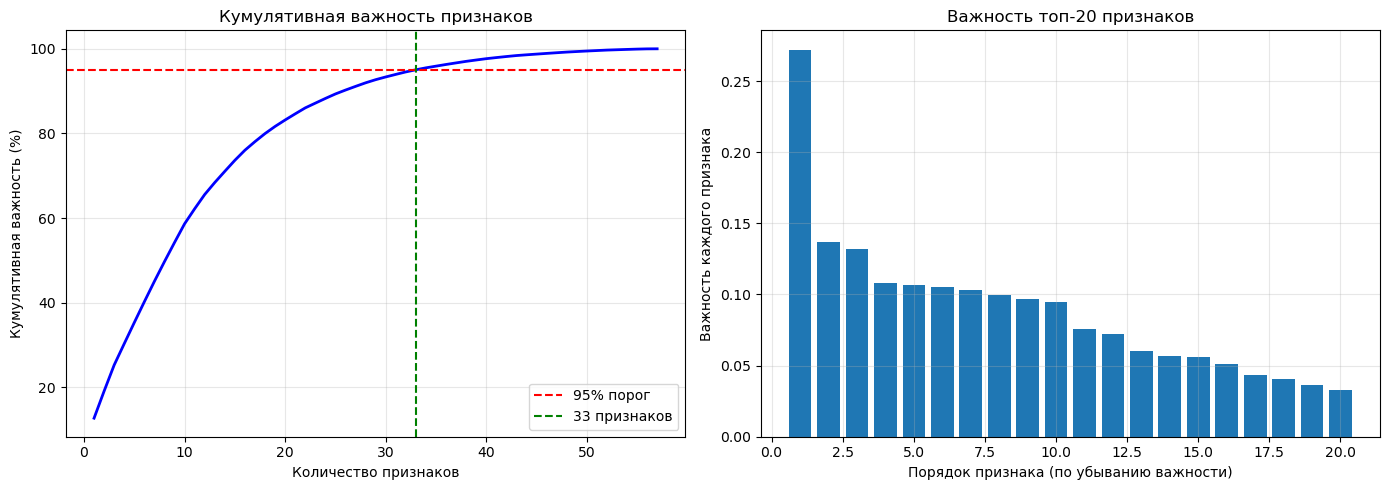

Для покрытия 95% важности нужно 33 признаков из 57
Для покрытия 99% важности нужно 47 признаков


In [23]:
feature_importance_sorted = feature_importance.sort_values('importance_abs', ascending=False)
cumulative_importance = np.cumsum(feature_importance_sorted['importance_abs'])
total_importance = cumulative_importance.iloc[-1]
cumulative_percentage = (cumulative_importance / total_importance) * 100

# Находим, сколько признаков нужно для 95%
n_95 = np.argmax(cumulative_percentage >= 95) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Кумулятивная важность
ax1.plot(range(1, len(cumulative_percentage) + 1), 
         cumulative_percentage, 'b-', linewidth=2)
ax1.axhline(y=95, color='r', linestyle='--', label='95% порог')
ax1.axvline(x=n_95, color='g', linestyle='--', label=f'{n_95} признаков')
ax1.set_xlabel('Количество признаков')
ax1.set_ylabel('Кумулятивная важность (%)')
ax1.set_title('Кумулятивная важность признаков')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: Прибыль от добавления каждого признака
ax2.bar(range(1, 21), feature_importance_sorted['importance_abs'].head(20))
ax2.set_xlabel('Порядок признака (по убыванию важности)')
ax2.set_ylabel('Важность каждого признака')
ax2.set_title('Важность топ-20 признаков')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Для покрытия 95% важности нужно {n_95} признаков из {len(feature_importance_sorted)}")
print(f"Для покрытия 99% важности нужно {np.argmax(cumulative_percentage >= 99) + 1} признаков")

In [24]:
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, log_loss, brier_score_loss,
                             confusion_matrix, roc_curve, precision_recall_curve)

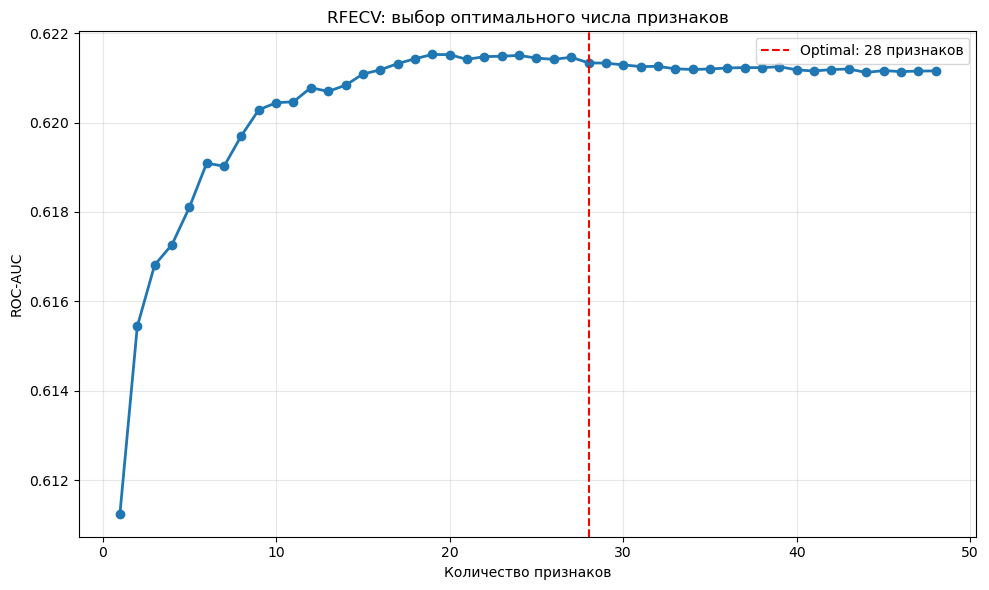

In [25]:
from sklearn.feature_selection import RFECV
rfecv = RFECV(estimator=LogisticRegression(max_iter=1000, random_state=42),
              step=1, cv=5, scoring='roc_auc', n_jobs=-1,min_features_to_select=10)
rfecv.fit(X_train_scaled, y_train_xgb)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
        rfecv.cv_results_['mean_test_score'], 'o-', linewidth=2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--', 
           label=f'Optimal: {rfecv.n_features_} признаков')
ax.set_xlabel('Количество признаков')
ax.set_ylabel('ROC-AUC')
ax.set_title('RFECV: выбор оптимального числа признаков')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

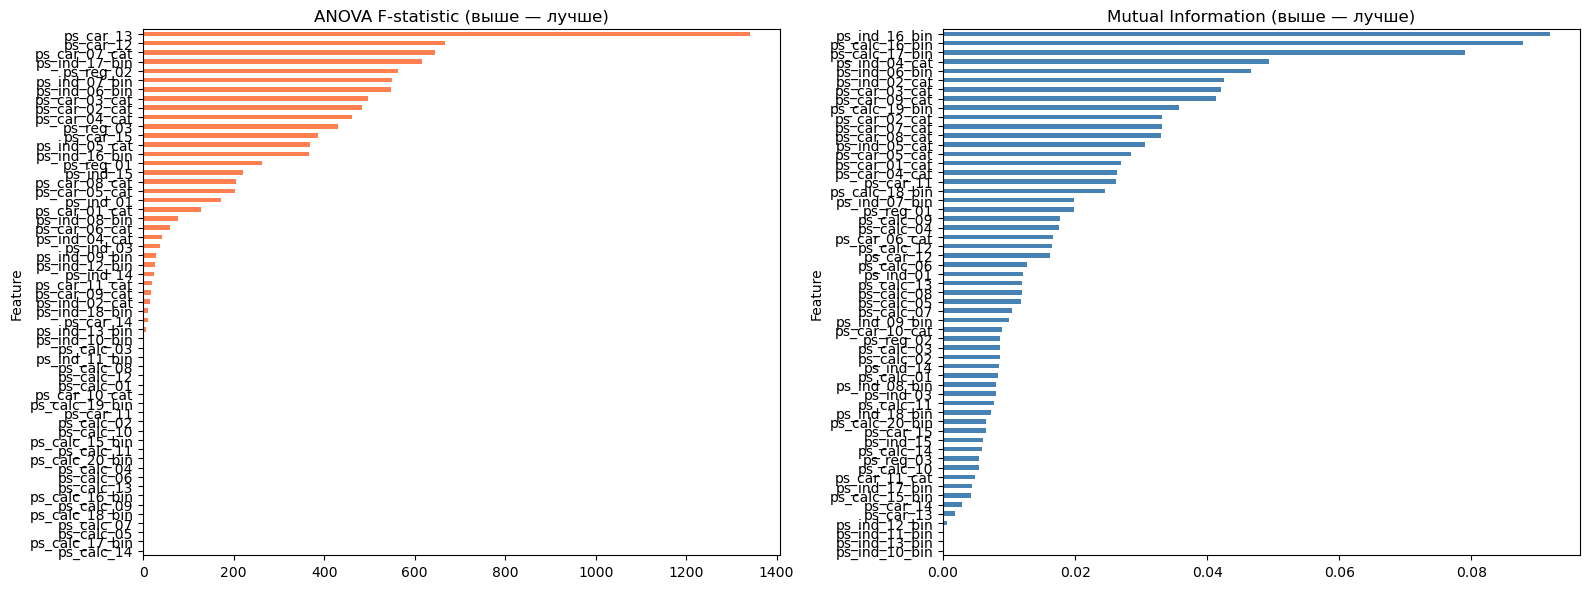

In [27]:
f_selector = SelectKBest(f_classif, k=28).fit(X_train_scaled, y_train_xgb)
mi_selector = SelectKBest(mutual_info_classif, k=28).fit(X_train_scaled, y_train_xgb)
scores_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'F-statistic': f_selector.scores_,
    'Mutual Information': mi_selector.scores_
}).sort_values('F-statistic', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scores_df.sort_values('F-statistic').plot.barh(x='Feature', y='F-statistic', ax=axes[0], 
                                               color='coral', legend=False)
axes[0].set_title('ANOVA F-statistic (выше — лучше)')
scores_df.sort_values('Mutual Information').plot.barh(x='Feature', y='Mutual Information', ax=axes[1], 
                                                        color='steelblue', legend=False)
axes[1].set_title('Mutual Information (выше — лучше)')
plt.tight_layout()
plt.show()

При сравнении методов отбора признаков по ANOVA F-statistic и Mutual Information, мы не можем уверенно сказать какие признаки лучше оставить, а какие удалить, поэтому воспользуемся последним методом отбора это permutation_importance

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model,X_train_scaled, y_train_xgb, n_repeats=10, random_state=42, n_jobs=-1)
importance_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'importance_mean': result.importances_mean*100
}).sort_values('importance_mean', ascending=False)

как мы видим данный метод также не дал интерпретируемых результатов какие признаки являются наиболее значимыми, но тем не менее он дал такое количество
признаков, как и RFCE,которые при перемешивании данных не снижают качество предсказания модели, а именно 28

In [29]:
importance_df

,feature,importance_mean
27,ps_car_07_cat,0.513851
8,ps_ind_09_bin,0.422980
16,ps_ind_17_bin,0.279943
29,ps_car_09_cat,0.180839
14,ps_ind_15,0.163156
17,ps_ind_18_bin,0.163009
32,ps_car_11,0.156646
4,ps_ind_05_cat,0.112376
23,ps_car_03_cat,0.101876
2,ps_ind_03,0.093517


In [30]:
(importance_df['importance_mean'] > 0).sum()

np.int64(28)

Гипотеза: После сокращения признаков до 28 по permutation_importance и использования другой модели - XGBClassifier ROC-AUC должен увеличится

In [31]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [32]:
import xgboost as xgb
import optuna

Посчитав важность признаков на одной модели и использовав эти признаки на другой модели, я добился худшего результата по ROC-AUC чем было до этого, попробуем теперь обучить модель на всех признаках и посмотреть какие их них наиболее важны при повторном обучении

In [33]:
y_cls = train_data['target']
X_cls = train_data.drop('target',axis=1)
X_train_cls,X_test_cls,y_train_cls,y_test_cls = train_test_split(X_cls,y_cls,test_size=0.2, random_state=42)
X_train_cls = X_train_cls.drop('id',axis = 1)
X_test_cls = X_test_cls.drop('id',axis = 1)
model1 = xgb.XGBClassifier(n_estimators=100,       
    learning_rate=0.1,      
    max_depth=5,            
    random_state=42,
    n_jobs=-1               
)
model1.fit(X_train_cls, y_train_cls)
y_proba_cls = model1.predict_proba(X_test_cls)[:, 1]
roc_auc = roc_auc_score(y_test_cls, y_proba_cls)
print(f"ROC-AUC: {roc_auc:.3f}")

ROC-AUC: 0.641


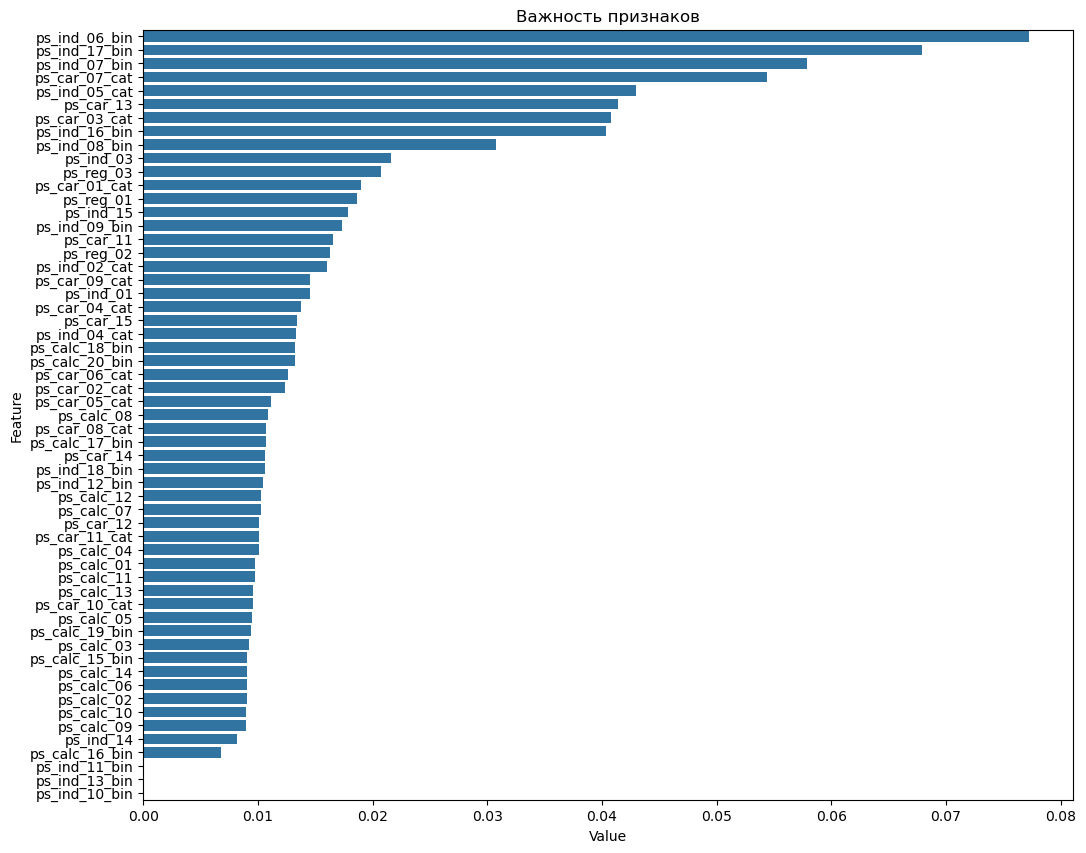

In [34]:
feature_imp = pd.DataFrame({
    'Value': model1.feature_importances_,
    'Feature': X_train_cls.columns
})
feature_imp = feature_imp.sort_values(by="Value", ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 10))
sns.barplot(x="Value", y="Feature", data=feature_imp) 
plt.title('Важность признаков')
plt.show()

In [39]:
rfecv = RFECV(estimator=xgb.XGBClassifier(max_iter=1000, random_state=42,step=1, cv=5, scoring='roc_auc', n_jobs=-1,min_features_to_select=10)
rfecv.fit(X_train_cls, y_train_cls)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
        rfecv.cv_results_['mean_test_score'], 'o-', linewidth=2)
ax.axvline(rfecv.n_features_, color='red', linestyle='--', 
           label=f'Optimal: {rfecv.n_features_} признаков')
ax.set_xlabel('Количество признаков')
ax.set_ylabel('ROC-AUC')
ax.set_title('RFECV: выбор оптимального числа признаков')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SyntaxError: '(' was never closed (121731094.py, line 1)

In [ ]:
calc_columns = [i for i in 